<a href="https://colab.research.google.com/github/Apoorv-Krishn-DAS/Apoorv-Krishn-DAS/blob/main/Prediction_Of_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediction_Of_Diabetes**

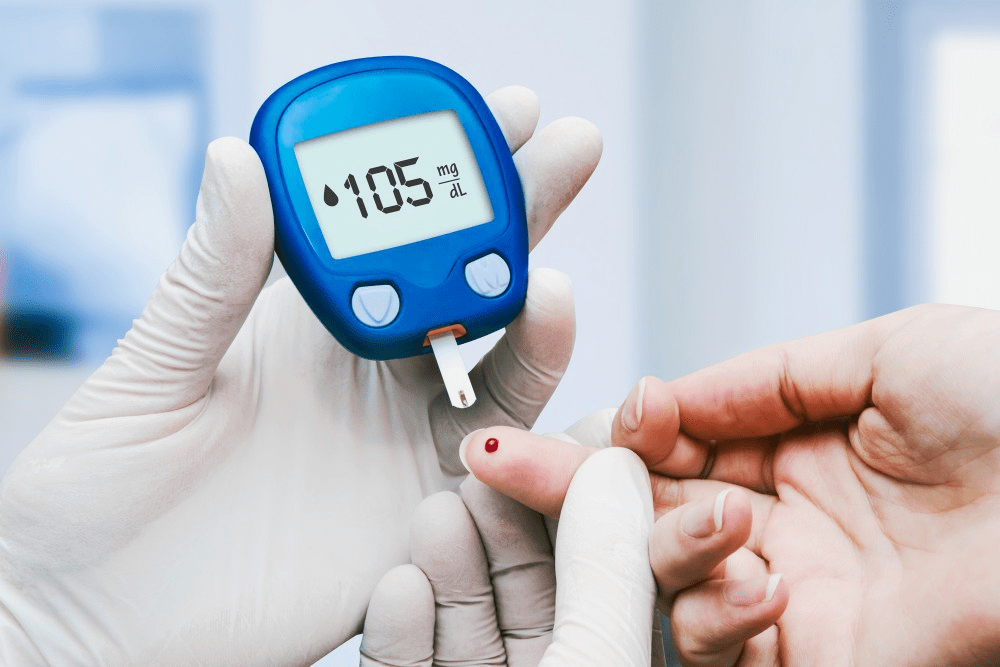

**Importing Required Libraries**

In [1]:
# ==============================
# Core Libraries
# ==============================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Sklearn - Model Selection
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

# ==============================
# Preprocessing & Pipelines
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==============================
# Machine Learning Models
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# ==============================
# Evaluation Metrics
# ==============================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# ==============================
# Handling Imbalanced Data
# ==============================

from imblearn.over_sampling import SMOTE

**Importing CSV File**

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**Shape of Dataset**

In [3]:
df.shape

(100000, 9)

**Checking Null Counts**

In [4]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

**Duplicate Values Count**

In [5]:
df.duplicated().sum()

3854

**Remove Duplicate Values**

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(96146, 9)

**Columns in DataFrame**

In [8]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

**Unique Values in Given Columns**

In [9]:
columns = ["gender", "hypertension", "heart_disease", "smoking_history", "diabetes"]

for col in columns:
    print(col, df[col].unique())

gender ['Female' 'Male' 'Other']
hypertension [0 1]
heart_disease [1 0]
smoking_history ['never' 'No Info' 'current' 'former' 'ever' 'not current']
diabetes [0 1]


In [10]:
df[df['gender'] == "Other"].shape

(18, 9)

In [11]:
df[df['smoking_history'] == "No Info"].shape

(32887, 9)

In [12]:
df[df['smoking_history'] == "not current"].shape

(6367, 9)

In [13]:
df[df['smoking_history'] == "former"].shape

(9299, 9)

**Summary of DataFrame**

In [14]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


**Smoking History Distribution**

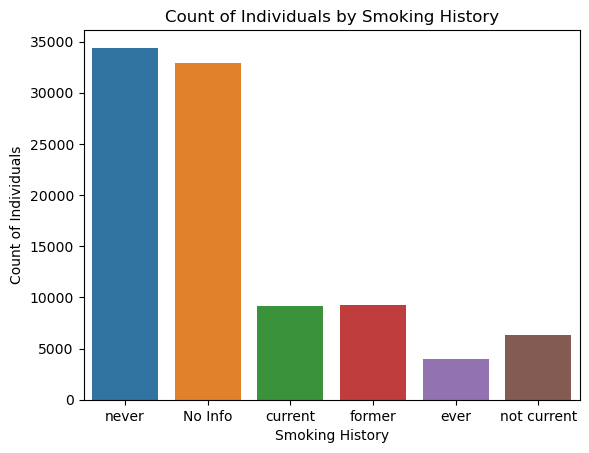

In [15]:
sns.countplot(x='smoking_history', data=df)
plt.title('Count of Individuals by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count of Individuals')
plt.show()

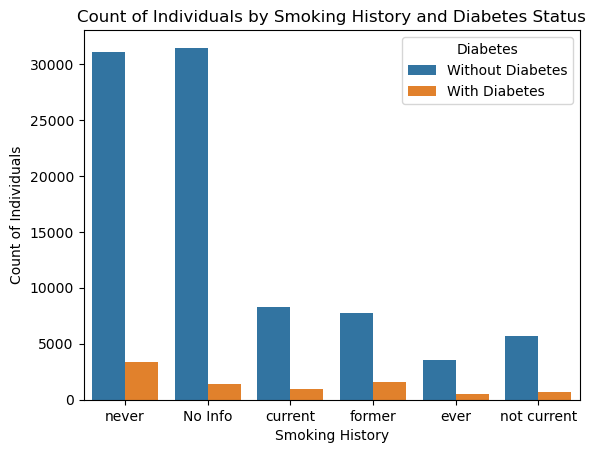

In [16]:
# Filter data based on Smoking history and diabetes status
never1 = df[(df['smoking_history'] == 'never') & (df['diabetes'] == 1)]
never0 = df[(df['smoking_history'] == 'never') & (df['diabetes'] == 0)]
noinfo1 = df[(df['smoking_history'] == 'No Info') & (df['diabetes'] == 1)]
noinfo0 = df[(df['smoking_history'] == 'No Info') & (df['diabetes'] == 0)]
current1 = df[(df['smoking_history'] == 'current') & (df['diabetes'] == 1)]
current0 = df[(df['smoking_history'] == 'current') & (df['diabetes'] == 0)]
former1 = df[(df['smoking_history'] == 'former') & (df['diabetes'] == 1)]
former0 = df[(df['smoking_history'] == 'former') & (df['diabetes'] == 0)]
ever1 = df[(df['smoking_history'] == 'ever') & (df['diabetes'] == 1)]
ever0 = df[(df['smoking_history'] == 'ever') & (df['diabetes'] == 0)]
notcurrent1 = df[(df['smoking_history'] == 'not current') & (df['diabetes'] == 1)]
notcurrent0 = df[(df['smoking_history'] == 'not current') & (df['diabetes'] == 0)]

# Combine the filtered data into a single DataFrame
smoking_history_df = pd.concat([never1, never0, noinfo1, noinfo0, current1, current0, former1, former0, ever1, ever0, notcurrent1, notcurrent0])

# Create the histogram
sns.countplot(x='smoking_history', hue='diabetes', data=smoking_history_df)
plt.xlabel('Smoking History')
plt.ylabel('Count of Individuals')
plt.title('Count of Individuals by Smoking History and Diabetes Status')
plt.legend(title='Diabetes', labels=['Without Diabetes', 'With Diabetes'])
plt.show()

**Gender Distribution**

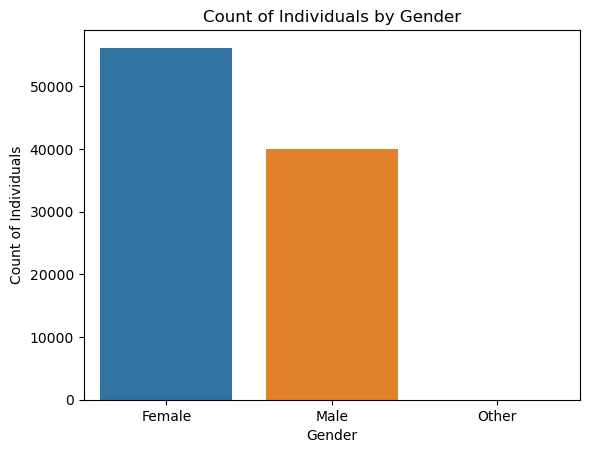

In [17]:
sns.countplot(x='gender', data=df)
plt.title('Count of Individuals by Gender')
plt.xlabel('Gender')
plt.ylabel('Count of Individuals')
plt.show()

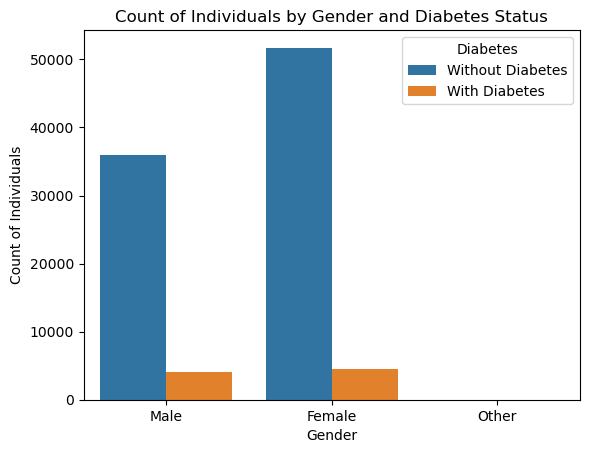

In [18]:
# Filter data based on gender and diabetes status
male1 = df[(df['gender'] == 'Male') & (df['diabetes'] == 1)]
male0 = df[(df['gender'] == 'Male') & (df['diabetes'] == 0)]
female1 = df[(df['gender'] == 'Female') & (df['diabetes'] == 1)]
female0 = df[(df['gender'] == 'Female') & (df['diabetes'] == 0)]
other1 = df[(df['gender'] == 'Other') & (df['diabetes'] == 1)]
other0 = df[(df['gender'] == 'Other') & (df['diabetes'] == 0)]

# Combine the filtered data into a single DataFrame
gender_df = pd.concat([male1, male0, female1, female0, other1, other0])

# Create the histogram using Seaborn
sns.countplot(x='gender', hue='diabetes', data=gender_df)
plt.xlabel('Gender')
plt.ylabel('Count of Individuals')
plt.title('Count of Individuals by Gender and Diabetes Status')
plt.legend(title='Diabetes', labels=['Without Diabetes', 'With Diabetes'])
plt.show()

**Age Distribution**

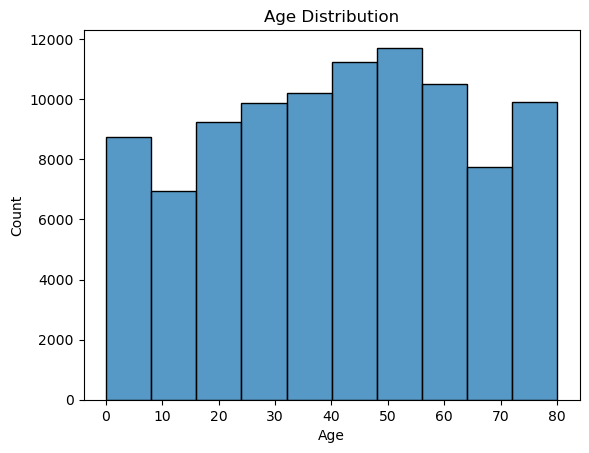

In [19]:
sns.histplot(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

We have age range from 0 to 80.

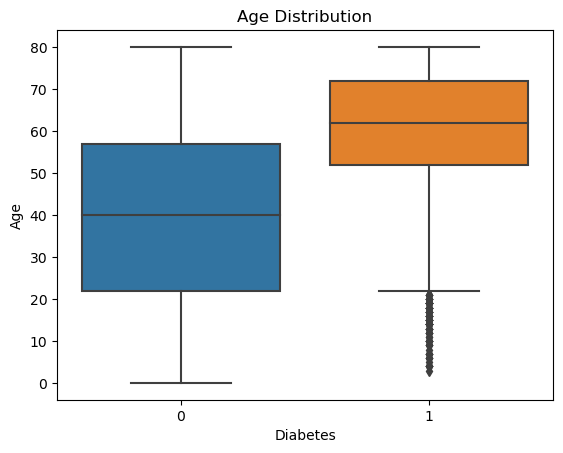

In [20]:
sns.boxplot(x=df['diabetes'], y=df['age'])
plt.title('Age Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.show()

Age-related changes, sedentary lifestyles, higher body weight, genetic factors, concurrent medical illnesses, certain medications, poor food, chronic inflammation, and decreased awareness and screening make older people more vulnerable to diabetes. Age-related changes in lifestyle, consistent exercise, a balanced diet, and the right medical treatment can help lower the risk of and manage diabetes.

**Hypertension Distribution**

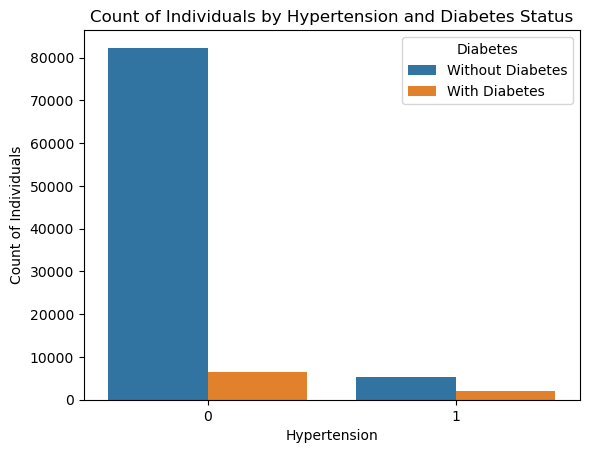

In [21]:
# Filter data based on hypertension and diabetes status
hypertension1 = df[(df['hypertension'] == 1) & (df['diabetes'] == 1)]
hypertension0 = df[(df['hypertension'] == 1) & (df['diabetes'] == 0)]
nohypertension1 = df[(df['hypertension'] == 0) & (df['diabetes'] == 1)]
nohypertension0 = df[(df['hypertension'] == 0) & (df['diabetes'] == 0)]

# Combine the filtered data into a single DataFrame
hypertension_df = pd.concat([hypertension1, hypertension0, nohypertension1, nohypertension0])

# Create the histogram using Seaborn
sns.countplot(x='hypertension', hue='diabetes', data=hypertension_df)
plt.xlabel('Hypertension')
plt.ylabel('Count of Individuals')
plt.title('Count of Individuals by Hypertension and Diabetes Status')
plt.legend(title='Diabetes', labels=['Without Diabetes', 'With Diabetes'])
plt.show()

People with hypertension are more susceptible to diabetes.

**Heart Disease Distribution**

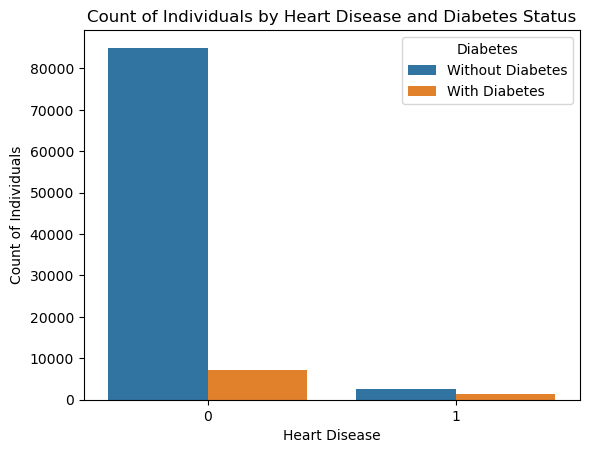

In [22]:
# Filter data based on heart_disease and diabetes status
heart_disease1 = df[(df['heart_disease'] == 1) & (df['diabetes'] == 1)]
heart_disease0 = df[(df['heart_disease'] == 1) & (df['diabetes'] == 0)]
no_heart_disease1 = df[(df['heart_disease'] == 0) & (df['diabetes'] == 1)]
no_heart_disease0 = df[(df['heart_disease'] == 0) & (df['diabetes'] == 0)]

# Combine the filtered data into a single DataFrame
heart_disease_df = pd.concat([heart_disease1, heart_disease0, no_heart_disease1, no_heart_disease0])

# Create the histogram using Seaborn
sns.countplot(x='heart_disease', hue='diabetes', data=heart_disease_df)
plt.xlabel('Heart Disease')
plt.ylabel('Count of Individuals')
plt.title('Count of Individuals by Heart Disease and Diabetes Status')
plt.legend(title='Diabetes', labels=['Without Diabetes', 'With Diabetes'])
plt.show()

People with heart disease are more susceptible to diabetes.

**BMI Distribution**

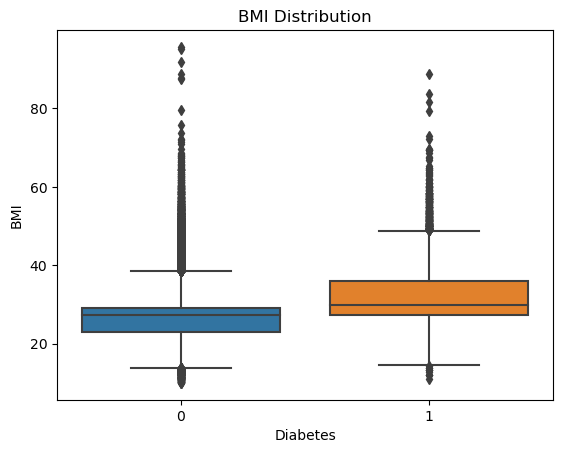

In [23]:
sns.boxplot(x=df['diabetes'], y=df['bmi'])
plt.title('BMI Distribution')
plt.xlabel('Diabetes')
plt.ylabel('BMI')
plt.show()

**HbA1c Level Distribution**

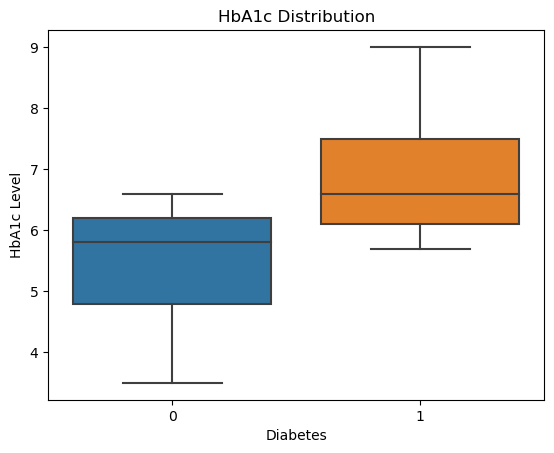

In [24]:
sns.boxplot(x=df['diabetes'], y=df['HbA1c_level'])
plt.title('HbA1c Distribution')
plt.xlabel('Diabetes')
plt.ylabel('HbA1c Level')
plt.show()

**Blood Glucose Level Distribution**

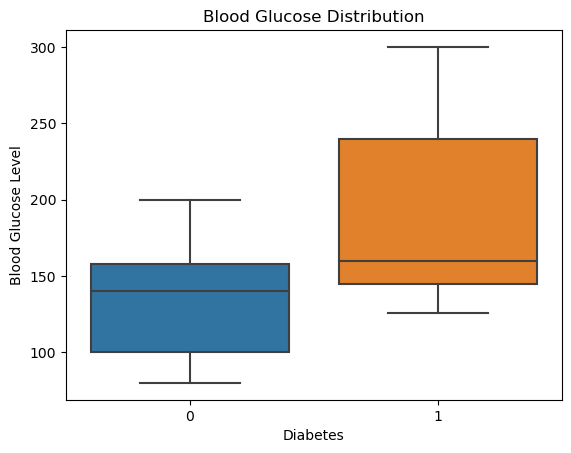

In [25]:
sns.boxplot(x=df['diabetes'], y=df['blood_glucose_level'])
plt.title('Blood Glucose Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Blood Glucose Level')
plt.show()

**Correlation Heatmap**

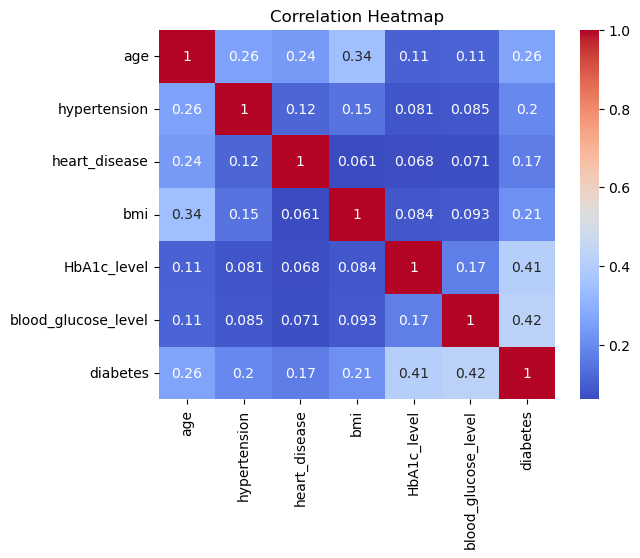

In [26]:
corr = df[['age', 'hypertension', 'heart_disease',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **Doing One-Hot Encoding of 'gender' and 'smoking_history' columns**

In [27]:
dummy_df = pd.get_dummies(df[["gender","smoking_history"]], drop_first=True)
dummy_df.head()

,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0
2,1,0,0,0,0,1,0
3,0,0,1,0,0,0,0
4,1,0,1,0,0,0,0


**Concatinating One-Hot Encoding columns with other columns**

In [28]:
X = pd.concat([df[['age','hypertension','heart_disease','bmi','HbA1c_level','blood_glucose_level']],dummy_df], axis=1)
X.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,1,0,1,0,0,0,0


**Scaling strategy**

No global MinMax scaling is used. Feature scaling is handled inside model pipelines where needed (Logistic Regression and SVM).

In [29]:
# Removed global MinMaxScaler to avoid double scaling and leakage.
# StandardScaler is applied only inside relevant pipelines.

**Defining y**

In [30]:
y = df['diabetes']

**Value Counts of y; is person diabetic or not**

In [31]:
y.value_counts()

0    87664
1     8482
Name: diabetes, dtype: int64

**SMOTE**

In [32]:
smote = SMOTE(sampling_strategy="minority", random_state=42)
X, y = smote.fit_resample(X, y)

y.value_counts()

0    87664
1    87664
Name: diabetes, dtype: int64

In [33]:
print(X.shape)

(175328, 13)


**Defining with different algorithms with there parameters**

In [34]:
algos = {

    'logistic_regression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000))
        ]),
        'params': {
            'model__C': [0.1, 1, 10]
        }
    },

    'decision_tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 10]
        }
    },

    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
        }
    },

    'gradient_boosting': {
        'model': GradientBoostingClassifier(),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1]
        }
    },

    'gaussian_nb': {
        'model': GaussianNB(),
        'params': {
        }
    }
}

**Train/test split + RandomizedSearchCV model training**

Split the balanced data and train each algorithm with cross-validation using only training data.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scores = []
best_estimators = {}

for algo_name, mp in algos.items():
    print(f"Training: {algo_name}", flush=True)

    # Keep algos structure as-is; provide a lightweight fallback for models with empty params.
    param_distributions = mp["params"] if mp["params"] else {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    }

    reg = RandomizedSearchCV(
        estimator=mp["model"],
        param_distributions=param_distributions,
        n_iter=5,
        cv=3,
        scoring="roc_auc",
        return_train_score=False,
        n_jobs=-1,
        random_state=42
    )

    reg.fit(X_train, y_train)
    best_estimators[algo_name] = reg.best_estimator_

    scores.append({
        "model": algo_name,
        "best_score": reg.best_score_,
        "best_params": reg.best_params_
    })

score_df = pd.DataFrame(scores, columns=["model", "best_score", "best_params"])
score_df = score_df.sort_values(by="best_score", ascending=False).reset_index(drop=True)

print("Training complete")

Training: logistic_regression


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training: decision_tree
Training: random_forest
Training: gradient_boosting


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training: gaussian_nb
Training complete


**Model comparison table (sorted by best_score)**

In [36]:
score_df = pd.DataFrame(scores, columns=["model", "best_score", "best_params"])
score_df = score_df.sort_values(by="best_score", ascending=False).reset_index(drop=True)
score_df

,model,best_score,best_params
0,random_forest,0.995915,"{'n_estimators': 100, 'max_depth': None}"
1,gradient_boosting,0.994828,"{'n_estimators': 100, 'learning_rate': 0.1}"
2,decision_tree,0.982768,"{'max_depth': 10, 'criterion': 'gini'}"
3,logistic_regression,0.970163,{'model__C': 0.1}
4,gaussian_nb,0.949136,{'var_smoothing': 1e-05}


**Model comparison visualization**

Horizontal bar chart of ROC-AUC scores to quickly identify the strongest model.

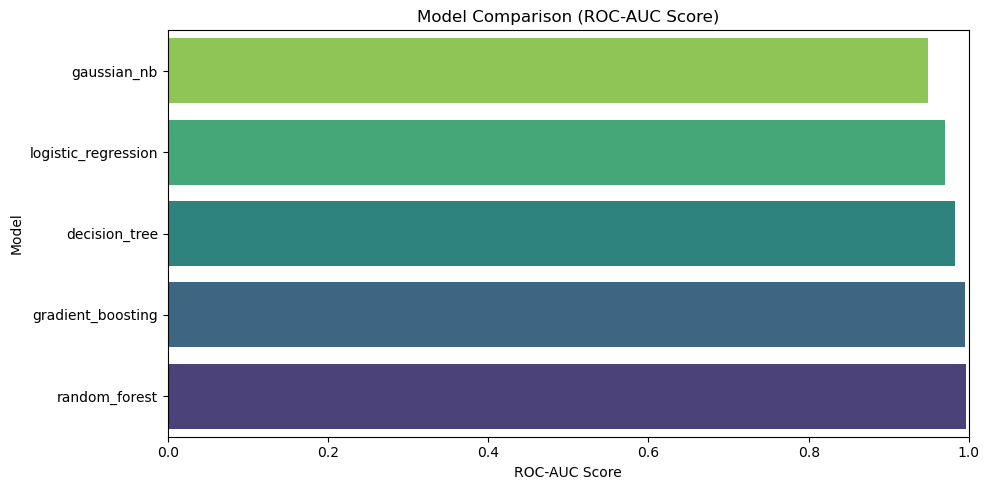

In [37]:
plot_df = score_df.sort_values(by="best_score", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="best_score", y="model", palette="viridis")
plt.gca().invert_yaxis()  # Best score on top
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")
plt.title("Model Comparison (ROC-AUC Score)")
plt.xlim(0.0, 1.0)
plt.tight_layout()
plt.show()

**Evaluate best model on test data**

In [38]:
best_model_name = score_df.loc[0, "model"]
best_model = best_estimators[best_model_name]

if hasattr(best_model, "predict_proba"):
    y_test_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_test_score = best_model.decision_function(X_test)

y_test_pred = best_model.predict(X_test)
test_roc_auc = roc_auc_score(y_test, y_test_score)

print(f"Best model: {best_model_name}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(classification_report(y_test, y_test_pred))

Best model: random_forest
Test ROC-AUC: 0.9968
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     17439
           1       0.98      0.97      0.97     17627

    accuracy                           0.97     35066
   macro avg       0.97      0.97      0.97     35066
weighted avg       0.97      0.97      0.97     35066



In [46]:
from sklearn.calibration import CalibratedClassifierCV

In [47]:
# Calibrate the model to improve probability estimates

calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid')

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(estimator=RandomForestClassifier())

Test the calibrated model

In [48]:
y_pred_cal = calibrated_model.predict(X_test)
y_prob_cal = calibrated_model.predict_proba(X_test)[:,1]

print("Calibrated Model Results")
print(classification_report(y_test, y_pred_cal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cal))

Calibrated Model Results
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17439
           1       0.97      0.97      0.97     17627

    accuracy                           0.97     35066
   macro avg       0.97      0.97      0.97     35066
weighted avg       0.97      0.97      0.97     35066

ROC-AUC: 0.9967925884490582


In [49]:
cm = confusion_matrix(y_test, y_test_pred)
cm

array([[17015,   424],
       [  557, 17070]], dtype=int64)

**Confusion matrix for best model (test set)**

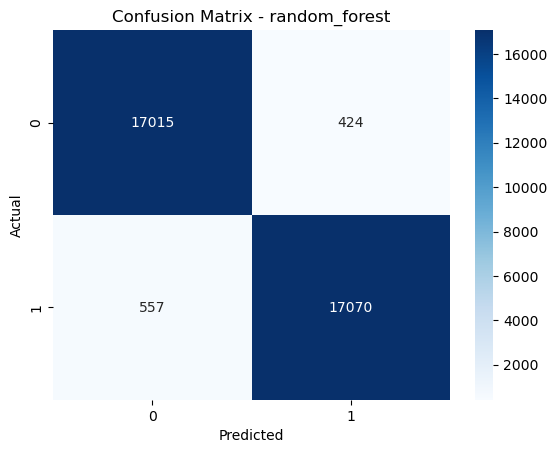

In [50]:
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

ROC Curve (Model Performance Visualization)

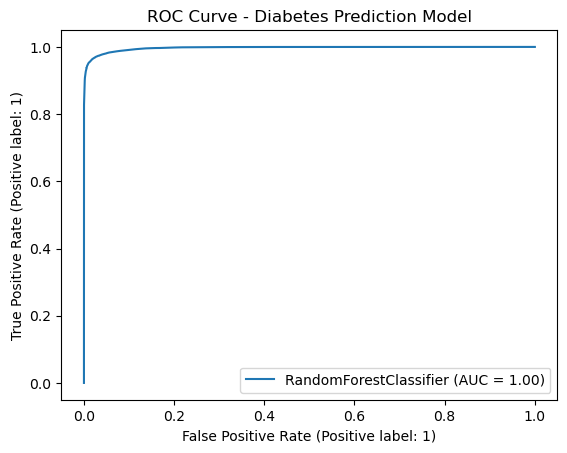

In [51]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curve - Diabetes Prediction Model")
plt.show()

Feature Importance Chart

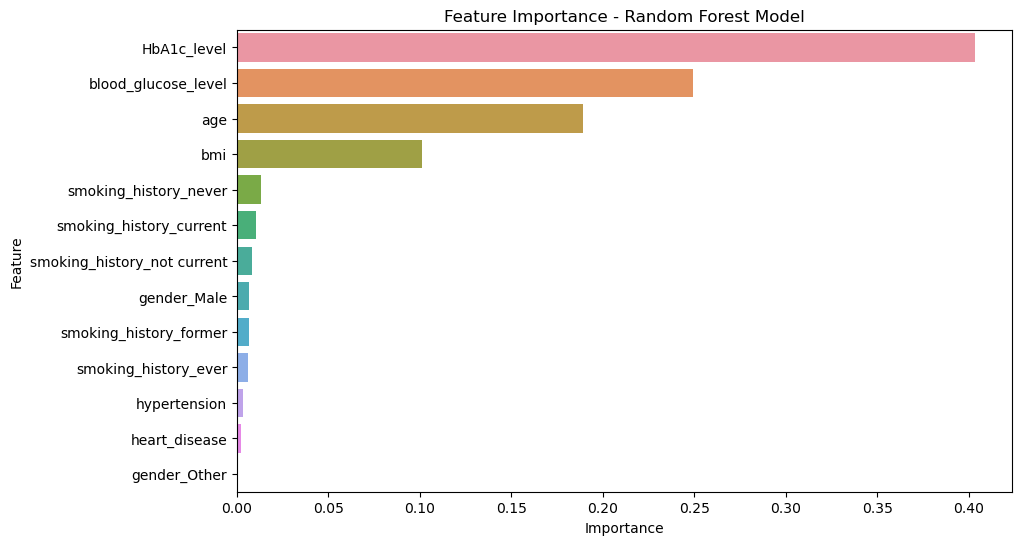

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")

plt.title("Feature Importance - Random Forest Model")
plt.show()

Probability Prediction

In [53]:
sample_patient = X_test.iloc[0].values.reshape(1,-1)

prediction = best_model.predict(sample_patient)
probability = best_model.predict_proba(sample_patient)

print("Prediction:", "Diabetic" if prediction[0] == 1 else "Not Diabetic")
print("Probability of Diabetes:", probability[0][1])

Prediction: Diabetic
Probability of Diabetes: 0.99


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


top 5 important features

In [54]:
feature_importance.head(5)

,Feature,Importance
4,HbA1c_level,0.403572
5,blood_glucose_level,0.249532
0,age,0.189079
3,bmi,0.101192
11,smoking_history_never,0.013272


Save the calibrated model

In [55]:
import pickle

with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(calibrated_model, f)

print("Calibrated model saved successfully")

Calibrated model saved successfully
